# Tomografia quântica para N qubits: versão generalizada

Mesma estrutura do notebook original, com as células na mesma ordem.
Legenda dos comentários nas células de código:

- `# [NOVO]`: trecho que não existia no seu código
- `# [ALTERADO]`: trecho que existia e foi modificado (o comentário diz o que mudou)
- `# [SEM ALTERAÇÃO]`: igual ao original

In [2]:
# Código para resolver o problema de tomografia quântica para N q-bits.
import numpy as np
from scipy.optimize import minimize, least_squares
import matplotlib.pyplot as plt
import cvxpy as cp
import itertools   
import time  
from tqdm import tqdm    

In [3]:
# [SEM ALTERAÇÃO]
# QuantState já funciona para N qubits: basta passar um vetor de tamanho 2**N
# (estado puro) ou uma matriz 2**N x 2**N (estado misto).
class QuantState:
    def __init__(self, estado):
        """
        Aceita um vetor 1D (estado puro) ou uma matriz 2D (matriz densidade / estado misto).
        """
        estado = np.array(estado, dtype=complex)

        if estado.ndim == 1:
            norma = np.linalg.norm(estado)
            psi = estado / norma
            self.rho = np.outer(psi, psi.conj())

        elif estado.ndim == 2:
            if estado.shape[0] != estado.shape[1]:
                raise ValueError("A matriz densidade deve ser quadrada.")
            traco = np.trace(estado)
            self.rho = estado / traco
        else:
            raise ValueError("O estado deve ser um vetor 1D (|psi>) ou matriz 2D (rho).")

    def measure(self, obs):
        """
        Mede o estado em relação a um observável (matriz hermitiana).
        Retorna o valor esperado <obs> = Tr(rho * obs).
        """
        return np.trace(self.rho @ obs).real

In [4]:
# [ALTERADO] Vetorizado (sem os dois for aninhados em Python) e sem np.abs na diagonal.
#
# Layout do vetor params (D*D números reais, D = 2**n_qubits):
#   params[0 : D]                    -> diagonal de T (reais)
#   params[D : D + D(D-1)/2]         -> parte REAL dos elementos abaixo da diagonal
#   params[D + D(D-1)/2 : D*D]       -> parte IMAGINÁRIA desses elementos
# (O layout é diferente do original, que intercalava real/imag. Não importa
#  para o otimizador; só o número de parâmetros, D*D, precisa bater.)
#
# Por que tirar o np.abs: trocar o sinal de uma LINHA inteira de T não muda
# T†T, então o sinal da diagonal é redundante, e o abs só deixava a função
# não diferenciável em 0.
def parametros_para_T_geral(params, n_qubits):
    """Constrói a matriz triangular inferior T para N qubits (D = 2^N)."""
    D = 2**n_qubits
    li, lj = np.tril_indices(D, k=-1)          # índices abaixo da diagonal
    n_off = len(li)                            # D(D-1)/2 elementos complexos

    T = np.zeros((D, D), dtype=complex)
    T[np.arange(D), np.arange(D)] = params[:D]
    T[li, lj] = params[D:D + n_off] + 1j * params[D + n_off:]
    return T


def parametros_para_rho_geral(params, n_qubits):
    """Gera rho para qualquer número de qubits."""
    T = parametros_para_T_geral(params, n_qubits)
    T_dag_T = T.conj().T @ T
    traco = np.trace(T_dag_T).real             # [ALTERADO] .real (o traço de T†T é real)

    if np.isclose(traco, 0):
        D = 2**n_qubits
        return np.eye(D, dtype=complex) / D

    return T_dag_T / traco

In [5]:

def funcao_de_custo_geral(params, mediadores_T, dados_exp, n_qubits):
    rho_candidato = parametros_para_rho_geral(params, n_qubits)
    previsoes = np.einsum('ij,mij->m', rho_candidato, mediadores_T).real
    return previsoes - dados_exp

In [6]:
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)


# [NOVO] Gera as 4**n - 1 strings de Pauli (todas menos I⊗...⊗I) via produto de Kronecker.
def gerar_paulis(n_qubits):
    I = np.eye(2, dtype=complex)
    base = [I, sigma_x, sigma_y, sigma_z]
    saida = []
    for combo in itertools.product(base, repeat=n_qubits):
        P = combo[0]
        for c in combo[1:]:
            P = np.kron(P, c)
        saida.append(P)
    return saida[1:]        # remove a identidade (o valor esperado dela é sempre 1)


# [NOVO] Fidelidade entre duas matrizes densidade: F = (Tr sqrt( sqrt(A) B sqrt(A) ))^2
def sqrt_psd(A):
    w, V = np.linalg.eigh((A + A.conj().T) / 2)
    return (V * np.sqrt(np.clip(w, 0, None))) @ V.conj().T

def fidelidade(rho_a, rho_b):
    sa = sqrt_psd(rho_a)
    return np.real(np.trace(sqrt_psd(sa @ rho_b @ sa)))**2

In [7]:

n_qubits = 5         
D = 2**n_qubits
np.random.seed(60)

todos_Q = gerar_paulis(n_qubits)


n_medidas = len(todos_Q)
mediadores_Q = todos_Q[:n_medidas]          


unk_state = QuantState(np.random.randn(D) + 1j * np.random.randn(D))

sigma_ruido = 0.0        # desvio padrão do ruído gaussiano (ex.: 0.01 para simular ruído)
q_medidos = np.array([unk_state.measure(Q) for Q in mediadores_Q])
q_medidos = q_medidos + np.random.normal(0, sigma_ruido, size=len(q_medidos))


# Para N qubits: soma dos quadrados dos valores esperados de Pauli <= 2**N - 1.
# (É condição necessária, não suficiente.)
limite = 2**n_qubits - 1
soma_q2 = np.sum(q_medidos**2)
if soma_q2 > limite + 1e-9:
    print(f"A soma dos quadrados das medidas ({soma_q2:.3f}) é maior que {limite}: "
          "os dados não correspondem a um estado físico.")


num_params = (2**n_qubits)**2
chute_inicial = np.random.randn(num_params)


mediadores_T = np.array(mediadores_Q).transpose(0, 2, 1)

"""
Exemplos para ilustrar possíveis situações:
1 - Se não tivermos medições suficientes (n_medidas < 4**n - 1), o estado reconstruído
não pode ser unicamente definido, e o algoritmo pode resultar em estados diferentes.
"""

t0 = time.time()   # [NOVO]
resultado1 = least_squares(
    funcao_de_custo_geral,
    x0=chute_inicial,
    args=(mediadores_T, q_medidos, n_qubits),   # [ALTERADO] mediadores_T no lugar de mediadores_Q
)


print(f"Tempo de uma otimização: {time.time() - t0:.2f} s")   

rho_reconstruido1 = parametros_para_rho_geral(resultado1.x, n_qubits=n_qubits)



if n_qubits <= 2:
    print("Rho Reconstruído 1:\n", np.round(rho_reconstruido1, 3))



for i in range(min(len(mediadores_Q), 4)):
    print(f"Q[{i}]: medido = {q_medidos[i]:+.4f} | "
          f"rec.1 = {np.trace(rho_reconstruido1 @ mediadores_Q[i]).real:+.4f} | ")


print("\nCusto final (0.5*soma dos resíduos^2):", resultado1.cost)
print("Fidelidade com o estado verdadeiro:",
      round(fidelidade(unk_state.rho, rho_reconstruido1), 6))



Tempo de uma otimização: 37.15 s
Q[0]: medido = +0.1033 | rec.1 = +0.1033 | 
Q[1]: medido = +0.0621 | rec.1 = +0.0621 | 
Q[2]: medido = +0.1286 | rec.1 = +0.1286 | 
Q[3]: medido = -0.0745 | rec.1 = -0.0745 | 

Custo final (0.5*soma dos resíduos^2): 3.721710446346077e-13
Fidelidade com o estado verdadeiro: 1.0


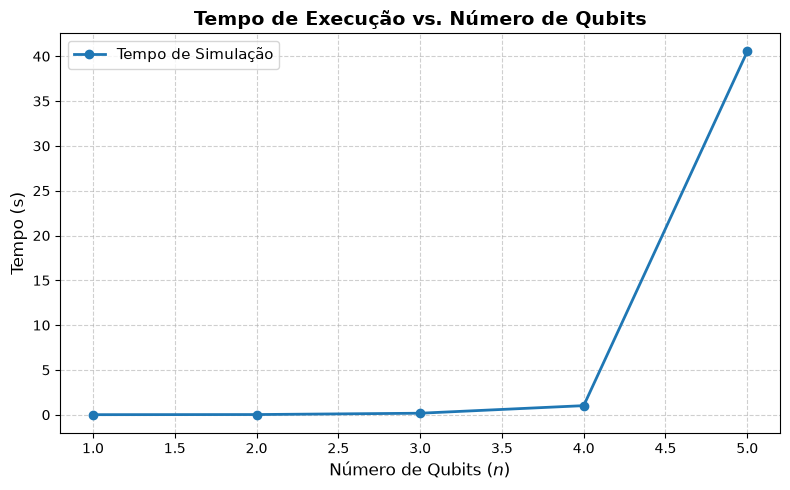

In [8]:
# Teste para plotar gráfico de n qubits x tempo
n_qubits_list = [1, 2, 3, 4, 5]
tempo_list = []
np.random.seed(60)

for n_qubits in n_qubits_list:
    D = 2**n_qubits

    todos_Q = gerar_paulis(n_qubits)


    n_medidas = len(todos_Q)
    mediadores_Q = todos_Q[:n_medidas]          


    unk_state = QuantState(np.random.randn(D) + 1j * np.random.randn(D))

    sigma_ruido = 0.0        # desvio padrão do ruído gaussiano (ex.: 0.01 para simular ruído)
    q_medidos = np.array([unk_state.measure(Q) for Q in mediadores_Q])
    q_medidos = q_medidos + np.random.normal(0, sigma_ruido, size=len(q_medidos))


    # Para N qubits: soma dos quadrados dos valores esperados de Pauli <= 2**N - 1.
    # (É condição necessária, não suficiente.)
    """
    limite = 2**n_qubits - 1
    soma_q2 = np.sum(q_medidos**2)
    if soma_q2 > limite + 1e-9:
        print(f"A soma dos quadrados das medidas ({soma_q2:.3f}) é maior que {limite}: "
            "os dados não correspondem a um estado físico.")
    """

    num_params = (2**n_qubits)**2
    chute_inicial = np.random.randn(num_params)


    mediadores_T = np.array(mediadores_Q).transpose(0, 2, 1)

    """
    Exemplos para ilustrar possíveis situações:
    1 - Se não tivermos medições suficientes (n_medidas < 4**n - 1), o estado reconstruído
    não pode ser unicamente definido, e o algoritmo pode resultar em estados diferentes.
    """

    t0 = time.time()   
    resultado = least_squares(
        funcao_de_custo_geral,
        x0=chute_inicial,
        args=(mediadores_T, q_medidos, n_qubits),   # [ALTERADO] mediadores_T no lugar de mediadores_Q
    )

    tempo_list.append(time.time() - t0)   # [NOVO]

    # print(f"Tempo de uma otimização: {time.time() - t0:.2f} s")   

    #rho_reconstruido = parametros_para_rho_geral(resultado.x, n_qubits=n_qubits)


    """
    if n_qubits <= 2:
        print("Rho Reconstruído 1:\n", np.round(rho_reconstruido, 3))



    for i in range(min(len(mediadores_Q), 4)):
        print(f"Q[{i}]: medido = {q_medidos[i]:+.4f} | "
            f"rec.1 = {np.trace(rho_reconstruido @ mediadores_Q[i]).real:+.4f} | ")

    
    print("\nCusto final (0.5*soma dos resíduos^2):", resultado.cost)
    print("Fidelidade com o estado verdadeiro:",
        round(fidelidade(unk_state.rho, rho_reconstruido), 6))
    """
         
    pass
plt.figure(figsize=(8, 5))

# Plotagem da linha com marcadores nos pontos de dados
plt.plot(
    n_qubits_list,
    tempo_list,
    marker='o',
    color='#1f77b4',
    linestyle='-',
    linewidth=2,
    label='Tempo de Simulação',
)

# Títulos e rótulos
plt.title('Tempo de Execução vs. Número de Qubits', fontsize=14, fontweight='bold')
plt.xlabel('Número de Qubits ($n$)', fontsize=12)
plt.ylabel('Tempo (s)', fontsize=12)

# Grade e legenda para melhor leitura
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Se o crescimento do tempo for exponencial, descomente a linha abaixo para usar escala logarítmica:
# plt.yscale('log')

plt.tight_layout()
plt.show()

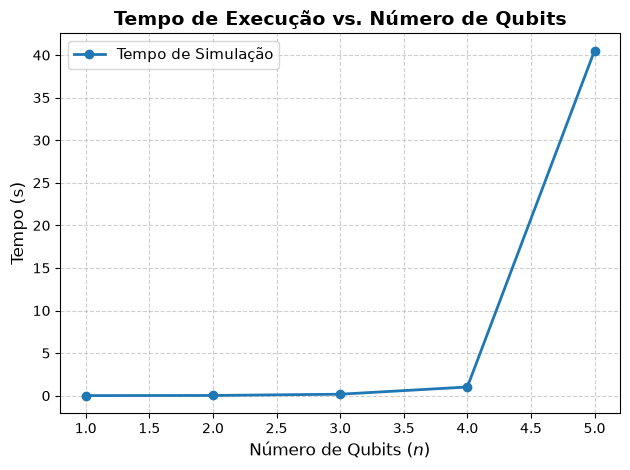

In [9]:
plt.plot(
    n_qubits_list,
    tempo_list,
    marker='o',
    color='#1f77b4',
    linestyle='-',
    linewidth=2,
    label='Tempo de Simulação',
)

# Títulos e rótulos
plt.title('Tempo de Execução vs. Número de Qubits', fontsize=14, fontweight='bold')
plt.xlabel('Número de Qubits ($n$)', fontsize=12)
plt.ylabel('Tempo (s)', fontsize=12)

# Grade e legenda para melhor leitura
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Se o crescimento do tempo for exponencial, descomente a linha abaixo para usar escala logarítmica:
# plt.yscale('log')

plt.tight_layout()
plt.show()

'''
if n_qubits == 1:
    try:
        from bloch_reconstrucao import plotar_bloch   # ou cole as funções no notebook
        plotar_bloch(
            [rho_reconstruido1, rho_reconstruido2],
            rotulos=["Reconstrução 1", "Reconstrução 2"],
            medidos=("x", "y"),
            salvar="bloch_reconstrucoes.png",
        )
    except ImportError:
        print("Módulo bloch_reconstrucao não encontrado; pulando o gráfico.")
        '''


In [10]:
"""Tentando fazer usando SDP"""
# [ALTERADO] Usa o MESMO estado, observáveis e dados da célula anterior
# (antes: d = 2, M = 3 fixos e q = np.random.rand(M), que podia dar problema infactível
# se soma(q^2) > 1). Aqui d = 2**n_qubits.
d = D                       # dimensão da matriz densidade
M = len(mediadores_Q)       # número de mediadores
rho = cp.Variable((d, d), hermitian=True)

Q = mediadores_Q            # observáveis
q = q_medidos               # valores esperados das medições

# Vínculos do problema
constraints = [
    rho >> 0,
    cp.trace(rho) == 1
]
for i in range(M):
    constraints.append(
        cp.real(cp.trace(Q[i] @ rho)) == q[i]
    )

# Problema de viabilidade semidefinida
problem = cp.Problem(cp.Minimize(0), constraints)
problem.solve()
print(problem.status)
# [NOVO] rho.value é None quando o problema é infactível (o que costuma acontecer se
# sigma_ruido > 0, pois as igualdades exatas deixam de ser compatíveis com um estado
# físico). Nesse caso use a versão de mínimos quadrados logo abaixo.
if problem.status == "optimal" and n_qubits <= 2:
    print(np.round(rho.value, 3))


# [NOVO] Versão SDP de mínimos quadrados (convexa): minimiza sum (Tr(Q rho) - q)^2
# com rho >= 0 e Tr(rho) = 1. Tem ótimo global (sem mínimo local) e aguenta ruído.
rho_ls = cp.Variable((d, d), hermitian=True)
previsoes = cp.hstack([cp.real(cp.trace(Q[i] @ rho_ls)) for i in range(M)])
problem_ls = cp.Problem(
    cp.Minimize(cp.sum_squares(previsoes - q)),
    [rho_ls >> 0, cp.trace(rho_ls) == 1],
)
problem_ls.solve()
print("SDP mínimos quadrados:", problem_ls.status, "| valor ótimo:", problem_ls.value)
print("Fidelidade com o estado verdadeiro:", round(fidelidade(unk_state.rho, rho_ls.value), 6))

optimal


/tmp/ipykernel_39935/1453059810.py:41: UserWarning: Objective contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  problem_ls.solve()
/tmp/ipykernel_39935/1453059810.py:41: UserWarning: Constraint #0 contains too many subexpressions. Consider vectorizing your CVXPY code to speed up compilation.
  problem_ls.solve()


SDP mínimos quadrados: optimal | valor ótimo: 3.5178842689213354e-11
Fidelidade com o estado verdadeiro: 0.999999
